
# Q2 联合搜索、Profile 稳定性与分月鲁棒性检查（逻辑修正版）

这份 Notebook 专门处理前面发现的两个逻辑问题：

1. **旧问题：** 原来的 W 敏感性是在 W=30 调出的其余参数固定条件下比较 W，因此只能解释为 conditional sensitivity；
2. **修正：** 现在对每个 W 都允许其余参数重新寻优，得到 profile sensitivity；
3. **进一步防止验证集偶然性：** 对每个 W 的 Top 配置做 May–Aug 分月稳定性检查，观察最优模型是否只是在某一个月份偶然表现好。

**Sep–Dec 独立测试集仍然完全锁住，不参与本 Notebook 的任何模型选择。**


In [2]:

from pathlib import Path
from io import StringIO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()

# ------------------------------------------------------------
# 结果读取策略：
# 1) 优先读取当前目录 / results / q2_joint_profile_results_v2 中的 CSV
# 2) 若本地不存在，则使用 Notebook 内嵌结果
# 因此单独拷贝本 Notebook 也可以正常阅读与画图。
# ------------------------------------------------------------

EMBEDDED = {
    "best": r"""W,load_id,pv_id,val_net_rmse,KL,KP,hL,hP,calL,calP,alphaL,alphaP
60,232,172,392.6232299804688,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
""",
    "byW": r"""W,load_id,pv_id,val_net_rmse,KL,KP,hL,hP,calL,calP,alphaL,alphaP
30,112,180,399.78033447265625,2,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual2,0.1,30.0
60,232,172,392.6232299804688,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
90,283,179,394.62701416015625,3,2,H2_lag1_lag7_mean7,H2_lag1_lag7_mean7,fri_sat,annual2,3.0,10.0
120,455,345,392.9381713867188,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
""",
    "prof": r"""parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
W,30,399.78033447265625,1.822893793763436,30,2,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual2,0.1,30.0
W,60,392.6232299804688,0.0,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
W,90,394.62701416015625,0.5103580294490317,90,3,2,H2_lag1_lag7_mean7,H2_lag1_lag7_mean7,fri_sat,annual2,3.0,10.0
W,120,392.9381713867188,0.0802146643910095,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
KL,1,416.1443176269531,5.99075292810729,30,1,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual2,0.1,30.0
KL,2,393.02142333984375,0.1014186958308016,60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0
KL,3,392.6232299804688,0.0,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
KL,4,392.7214660644531,0.0250204461894165,60,4,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,10.0
KL,5,392.9381713867188,0.0802146643910095,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
KP,1,401.156494140625,2.173397677101474,60,3,1,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,1.0,3.0
KP,2,392.6232299804688,0.0,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
KP,3,395.9150085449219,0.8384064704008765,120,5,3,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
KP,4,392.9381713867188,0.0802146643910095,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
hL,H0_lag1,392.6232299804688,0.0,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
hL,H1_lag1_lag7,393.02142333984375,0.1014186958308016,60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0
hL,H2_lag1_lag7_mean7,394.62701416015625,0.5103580294490317,90,3,2,H2_lag1_lag7_mean7,H2_lag1_lag7_mean7,fri_sat,annual2,3.0,10.0
hL,H3_lag1_lag7_mean7_trend7,394.9552612304688,0.5939616079557952,90,3,2,H3_lag1_lag7_mean7_trend7,H2_lag1_lag7_mean7,weekday7,annual2,0.1,10.0
hP,H0_lag1,392.9381713867188,0.0802146643910095,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
hP,H1_lag1_lag7,397.4976196289063,1.2414929317045242,120,5,2,H0_lag1,H1_lag1_lag7,weekday7,annual2,0.1,1.0
hP,H2_lag1_lag7_mean7,392.6232299804688,0.0,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
hP,H3_lag1_lag7_mean7_trend7,393.731689453125,0.2823214186056688,60,3,2,H0_lag1,H3_lag1_lag7_mean7_trend7,weekday7,annual1,0.3,3.0
calL,fri_sat,393.02142333984375,0.1014186958308016,60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0
calL,weekday7,392.6232299804688,0.0,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
calL,fri_sat+annual1,394.0928039550781,0.3742962367974112,60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual1,annual1,1.0,10.0
calL,fri_sat+annual2,393.9749450683594,0.3442779195611756,60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,1.0,10.0
calP,annual1,392.6232299804688,0.0,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
calP,annual2,392.9381713867188,0.0802146643910095,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
calP,weekday7+annual1,398.2601623535156,1.4357103560396212,120,5,4,H0_lag1,H2_lag1_lag7_mean7,weekday7,weekday7+annual1,0.1,30.0
calP,weekday7+annual2,397.4445495605469,1.227976138935527,120,5,4,H0_lag1,H2_lag1_lag7_mean7,weekday7,weekday7+annual2,0.1,30.0
alphaL,0.1,392.7214660644531,0.0250204461894165,60,4,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,10.0
alphaL,0.3,392.6232299804688,0.0,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
alphaL,1.0,393.3499755859375,0.1851000017255577,60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,1.0,10.0
alphaL,3.0,394.2745666503906,0.4205906690758043,60,3,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,3.0,3.0
alphaL,10.0,396.6416931152344,1.023490926648818,120,4,4,H1_lag1_lag7,H0_lag1,fri_sat,annual2,10.0,3.0
alphaL,30.0,403.6769409179688,2.815348174393528,120,4,4,H2_lag1_lag7_mean7,H0_lag1,fri_sat,annual2,30.0,3.0
alphaL,100.0,435.4960021972656,10.919570963472957,120,4,4,H3_lag1_lag7_mean7_trend7,H2_lag1_lag7_mean7,fri_sat+annual1,annual1,100.0,30.0
alphaP,0.1,398.4054260253906,1.47270859271611,120,5,2,H0_lag1,H0_lag1,weekday7,annual2,0.1,0.1
alphaP,0.3,395.3215026855469,0.6872422462655514,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,0.3
alphaP,1.0,392.9381713867188,0.0802146643910095,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
alphaP,3.0,392.7362060546875,0.0287746790286425,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,3.0
alphaP,10.0,392.6232299804688,0.0,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
alphaP,30.0,395.1183471679688,0.6354991240900665,120,5,4,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual2,0.1,30.0
alphaP,100.0,398.8843383789063,1.594686182666516,120,5,4,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual2,0.1,100.0
""",
    "stab": r"""parameter,best_value,candidate_count,max_rmse_increase_pct,median_rmse_increase_pct,max_other_parameter_changes,median_other_parameter_changes
W,60,4,1.822893793763436,0.2952863469200206,6,4.5
KL,3,5,5.99075292810729,0.0802146643910095,6,3.0
KP,2,4,2.173397677101474,0.459310567395943,6,4.0
hL,H0_lag1,4,0.5939616079557952,0.3058883626399167,4,3.0
hP,H2_lag1_lag7_mean7,4,1.2414929317045242,0.1812680414983392,6,3.0
calL,weekday7,4,0.3742962367974112,0.2228483076959886,3,1.0
calP,annual1,4,1.4357103560396212,0.6540954016632683,6,5.0
alphaL,0.3,7,10.919570963472957,0.4205906690758043,8,3.0
alphaP,10.0,7,1.594686182666516,0.6354991240900665,6,5.0
""",
    "top": r"""W,KL,KP,hL,hP,calL,calP,alphaL,alphaP,val_net_rmse,load_id,pv_id
60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0,392.6232299804688,232,172
60,4,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,10.0,392.7214660644531,343,172
60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,3.0,392.7362060546875,232,171
60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,10.0,392.74993896484375,231,172
60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,3.0,392.8122863769531,231,171
60,4,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0,392.89501953125,344,172
120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0,392.9381713867188,455,345
60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0,393.02142333984375,140,172
60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.3,10.0,393.1507873535156,141,172
60,4,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,3.0,393.2041320800781,343,171
60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,weekday7,annual1,0.1,10.0,393.23095703125,147,172
60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0,393.3196411132813,148,172
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,1.0,10.0,393.3499755859375,226,172
120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.3,1.0,393.4076843261719,456,345
60,4,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,3.0,393.46331787109375,344,171
60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,1.0,10.0,393.51763916015625,233,172
120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,3.0,393.5401306152344,455,346
60,2,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,10.0,393.5465393066406,119,172
60,5,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,10.0,393.6584777832031,455,172
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,0.3,10.0,393.66839599609375,225,172
60,3,2,H0_lag1,H3_lag1_lag7_mean7_trend7,weekday7,annual1,0.3,3.0,393.731689453125,232,199
60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,1.0,3.0,393.7478942871094,233,171
120,4,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0,393.75732421875,343,345
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,1.0,3.0,393.791748046875,226,171
60,3,2,H0_lag1,H3_lag1_lag7_mean7_trend7,weekday7,annual1,0.1,3.0,393.7961730957031,231,199
60,5,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0,393.87109375,456,172
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0,393.912109375,224,172
60,4,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,0.3,10.0,393.9402770996094,337,172
60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,1.0,10.0,393.9532165527344,142,172
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,1.0,10.0,393.9749450683594,247,172
60,2,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0,393.9751892089844,112,172
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,0.3,3.0,393.98443603515625,225,171
120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.3,3.0,393.9899291992188,456,346
60,4,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0,394.0000305175781,336,172
120,5,4,H1_lag1_lag7,H0_lag1,fri_sat,annual2,0.1,1.0,394.0140686035156,476,345
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,1.0,3.0,394.04498291015625,247,171
120,4,4,H0_lag1,H0_lag1,weekday7,annual2,0.3,1.0,394.0518798828125,344,345
60,3,2,H0_lag1,H3_lag1_lag7_mean7_trend7,weekday7,annual1,0.3,10.0,394.085693359375,232,200
60,2,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0,394.0858459472656,120,172
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual1,annual1,1.0,10.0,394.0928039550781,240,172
60,4,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,1.0,10.0,394.1015930175781,366,172
60,5,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,3.0,394.11859130859375,455,171
60,4,2,H0_lag1,H3_lag1_lag7_mean7_trend7,weekday7,annual1,0.1,3.0,394.1701354980469,343,199
60,4,2,H0_lag1,H3_lag1_lag7_mean7_trend7,weekday7,annual1,0.1,10.0,394.1778869628906,343,200
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,3.0,394.1867065429688,224,171
60,4,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,1.0,10.0,394.1900329589844,338,172
60,3,2,H0_lag1,H3_lag1_lag7_mean7_trend7,weekday7,annual1,0.1,10.0,394.20123291015625,231,200
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual1,annual1,1.0,3.0,394.2275695800781,240,171
60,5,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,0.3,10.0,394.2422790527344,449,172
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,0.3,3.0,394.2471618652344,246,171
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,0.3,10.0,394.250732421875,246,172
60,5,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0,394.260009765625,448,172
120,5,4,H1_lag1_lag7,H0_lag1,fri_sat,annual2,0.3,1.0,394.2622680664063,477,345
60,4,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0,394.2740173339844,364,172
60,3,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,3.0,3.0,394.2745666503906,276,171
60,4,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.3,10.0,394.2761840820313,365,172
120,4,4,H1_lag1_lag7,H0_lag1,weekday7,annual2,0.1,1.0,394.28509521484375,371,345
60,4,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,0.3,10.0,394.3029479980469,358,172
60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,weekday7,annual1,0.1,3.0,394.3107299804688,147,171
120,4,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,3.0,394.3138732910156,343,346
60,2,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,0.3,10.0,394.3246765136719,113,172
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,0.1,3.0,394.3326721191406,245,171
60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,weekday7,annual1,1.0,10.0,394.3338623046875,149,172
60,3,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,3.0,10.0,394.3649597167969,276,172
60,4,2,H0_lag1,H3_lag1_lag7_mean7_trend7,weekday7,annual1,0.3,10.0,394.365234375,344,200
60,4,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,0.1,10.0,394.3678283691406,357,172
60,4,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,1.0,10.0,394.3747863769531,359,172
60,3,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,1.0,3.0,394.3767700195313,275,171
120,3,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0,394.3878173828125,231,345
60,4,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,1.0,10.0,394.3943481445313,387,172
60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual2,0.3,10.0,394.3960571289063,232,179
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,0.1,10.0,394.41400146484375,245,172
120,4,4,H1_lag1_lag7,H0_lag1,fri_sat,annual2,0.1,1.0,394.4219665527344,364,345
60,5,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,3.0,394.4273071289063,456,171
60,4,2,H0_lag1,H3_lag1_lag7_mean7_trend7,weekday7,annual1,0.3,3.0,394.433837890625,344,199
120,4,4,H1_lag1_lag7,H0_lag1,fri_sat,annual2,1.0,1.0,394.435791015625,366,345
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual1,annual1,0.3,10.0,394.44183349609375,239,172
120,4,4,H0_lag1,H0_lag1,weekday7,annual2,1.0,1.0,394.4432067871094,345,345
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual1,annual1,0.3,3.0,394.4491882324219,239,171
120,4,4,H1_lag1_lag7,H0_lag1,fri_sat,annual2,0.3,1.0,394.45123291015625,365,345
120,5,4,H1_lag1_lag7,H0_lag1,fri_sat,annual2,1.0,1.0,394.4626159667969,478,345
120,5,4,H1_lag1_lag7,H0_lag1,fri_sat,annual2,0.1,3.0,394.4836120605469,476,346
60,2,2,H1_lag1_lag7,H3_lag1_lag7_mean7_trend7,fri_sat,annual1,0.1,10.0,394.4868774414063,140,200
120,5,4,H0_lag1,H0_lag1,weekday7,annual2,1.0,1.0,394.4870910644531,457,345
60,4,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual1,annual1,0.3,10.0,394.5003051757813,351,172
60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,3.0,10.0,394.5048522949219,227,172
60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual2,0.1,10.0,394.5144653320313,231,179
120,5,4,H1_lag1_lag7,H0_lag1,weekday7,annual2,0.1,1.0,394.542724609375,483,345
120,4,4,H0_lag1,H0_lag1,weekday7,annual2,0.3,3.0,394.5626525878906,344,346
60,3,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,3.0,10.0,394.5626831054688,255,172
60,4,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,1.0,3.0,394.5754089355469,387,171
60,4,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,1.0,3.0,394.585693359375,366,171
60,4,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual1,annual1,1.0,10.0,394.5876159667969,352,172
60,5,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,1.0,10.0,394.6019592285156,450,172
60,4,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat+annual1,annual1,1.0,10.0,394.6159362792969,380,172
60,2,2,H1_lag1_lag7,H3_lag1_lag7_mean7_trend7,fri_sat,annual1,0.3,10.0,394.6172790527344,141,200
90,3,2,H2_lag1_lag7_mean7,H2_lag1_lag7_mean7,fri_sat,annual2,3.0,10.0,394.62701416015625,283,179
60,4,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,0.1,3.0,394.63525390625,357,171
60,4,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.3,3.0,394.6446533203125,365,171
60,4,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,3.0,10.0,394.6448059082031,367,172
""",
    "monthly": r"""Index,rank,W,load_id,pv_id,overall_rmse,KL,hL,calL,alphaL,KP,hP,calP,alphaP,May_rmse,May_mae,Jun_rmse,Jun_mae,Jul_rmse,Jul_mae,Aug_rmse,Aug_mae,monthly_mean_rmse,monthly_sd_rmse,worst_month_rmse,best_month_rmse,monthly_cv_pct
0,1,60,232,172,392.6232299804688,3,H0_lag1,weekday7,0.3,2,H2_lag1_lag7_mean7,annual1,10.0,365.5953388622489,255.1477997482902,436.3567502233832,292.9224885611979,388.1036563528272,271.84219299360154,378.2722664739635,271.68108124829365,392.0820029781057,26.77840867099893,436.3567502233832,365.5953388622489,6.829797967670112
1,2,60,343,172,392.7214660644531,4,H0_lag1,weekday7,0.1,2,H2_lag1_lag7_mean7,annual1,10.0,365.6301048597536,255.94391255722863,439.833430397801,293.2918387025282,385.61929790517866,271.34909407250194,377.2861264637469,271.2474871312952,392.09223990662,28.46307183962704,439.833430397801,365.6301048597536,7.259279562994093
3,4,60,231,172,392.74993896484375,3,H0_lag1,weekday7,0.1,2,H2_lag1_lag7_mean7,annual1,10.0,365.1474044498905,254.96500911760228,439.1248848160436,293.99738008119937,387.30459555390337,271.28060563238546,376.9434905459823,270.64605423426474,392.130093841455,28.24223016567631,439.1248848160436,365.1474044498905,7.202260323609627
6,7,60,140,172,393.02142333984375,2,H1_lag1_lag7,fri_sat,0.1,2,H2_lag1_lag7_mean7,annual1,10.0,369.5091059407988,258.762611999293,448.16522812553615,298.24615700267645,379.9992376090451,271.52087686894464,370.9059575083065,266.9004377244956,392.14488229592166,32.59319763793731,448.16522812553615,369.5091059407988,8.311519315797604
2,3,60,232,171,392.7362060546875,3,H0_lag1,weekday7,0.3,2,H2_lag1_lag7_mean7,annual1,3.0,368.99090240146114,256.8178435780077,435.9667435031509,292.9734789334671,384.3685979281981,269.35194406187,379.6868373217078,272.0265713851874,392.2532702886295,25.84612541532158,435.9667435031509,368.99090240146114,6.589142111244445
4,5,60,231,171,392.8122863769531,3,H0_lag1,weekday7,0.1,2,H2_lag1_lag7_mean7,annual1,3.0,368.4860750320422,256.6234069551639,438.3705088359116,293.7758787598561,383.8548721744668,268.9693376204077,378.3282569100089,270.9881438657261,392.25992823810736,27.185097814598866,438.3705088359116,368.4860750320422,6.93037852138114
7,8,60,141,172,393.1507873535156,2,H1_lag1_lag7,fri_sat,0.3,2,H2_lag1_lag7_mean7,annual1,10.0,370.2541653287137,259.0796646109852,448.25486189132585,298.2133447902199,379.66905038636406,271.1910119436394,370.9401657982851,266.9673204557904,392.27956085117216,32.5297830067416,448.25486189132585,370.2541653287137,8.292500107871579
9,10,60,147,172,393.23095703125,2,H1_lag1_lag7,weekday7,0.1,2,H2_lag1_lag7_mean7,annual1,10.0,368.78227672465306,257.84513870433955,449.3236731232658,298.77786957311554,381.5487547720559,271.14654174060894,369.5609081788433,267.01157642638503,392.3039031997045,33.30704923281024,449.3236731232658,368.78227672465306,8.490114159240239
5,6,60,344,172,392.89501953125,4,H0_lag1,weekday7,0.3,2,H2_lag1_lag7_mean7,annual1,10.0,366.28083709007626,256.2570764950332,438.35299947435504,293.0629407344112,385.8662175030438,271.6239627110198,378.7838245694157,272.39594708549475,392.3209696592226,27.48615285784888,438.35299947435504,366.28083709007626,7.006037143954826
8,9,60,343,171,393.2041320800781,4,H0_lag1,weekday7,0.1,2,H2_lag1_lag7_mean7,annual1,3.0,369.0180282275072,257.66160734075737,438.7592368962,292.65053711602104,384.2870718907016,270.62474493740723,378.5499291120873,271.46723737631083,392.653566531624,27.172055184189965,438.7592368962,369.0180282275072,6.920109098767488
0,1,120,455,345,392.9381713867188,5,H0_lag1,weekday7,0.1,4,H0_lag1,annual2,1.0,370.1972604542415,257.5917751603978,427.139988748794,291.18226129932543,389.70606379476806,273.11706679429363,383.58963285839616,269.9781118091433,392.65823646405,21.12132559029721,427.139988748794,370.1972604542415,5.379060880143026
1,2,120,456,345,393.4076843261719,5,H0_lag1,weekday7,0.3,4,H0_lag1,annual2,1.0,372.4411873393919,259.1180569242307,427.0290100786582,291.9508006579589,389.090579554623,273.1106157520581,384.071038066219,270.2904362952229,393.157953759723,20.46673176657793,427.0290100786582,372.4411873393919,5.205727512532048
2,3,120,455,346,393.5401306152344,5,H0_lag1,weekday7,0.1,4,H0_lag1,annual2,3.0,366.1222314303345,256.38294380053446,430.1685120344865,293.57902156218347,391.2572675877607,273.62662825809605,385.09208417367824,271.2912245417332,393.16002380656505,23.28831546422184,430.1685120344865,366.1222314303345,5.923368108167503
3,4,120,343,345,393.75732421875,4,H0_lag1,weekday7,0.1,4,H0_lag1,annual2,1.0,368.8836013894886,256.3897108139421,430.2972472385765,294.2109584135381,390.2392450350092,272.5220772275426,384.2305968307221,270.16033245958994,393.4126726234491,22.674480912812893,430.2972472385765,368.8836013894886,5.763535973970909
4,5,120,456,346,393.9899291992188,5,H0_lag1,weekday7,0.3,4,H0_lag1,annual2,3.0,368.26581056034496,257.8615688404371,430.2918436845089,294.53015496631764,390.50495280048216,273.58320928740693,385.5030625737068,271.55319321232184,393.6414174047607,22.71148057029556,430.2918436845089,368.26581056034496,5.769586117240945
5,6,120,476,345,394.0140686035156,5,H1_lag1_lag7,fri_sat,0.1,4,H0_lag1,annual2,1.0,373.7895373242834,260.9251546439222,432.246317724073,294.7702058545826,386.3851998736672,272.4302116628339,382.30659444913584,269.3683530143491,393.6819123427899,22.72421514776461,432.246317724073,373.7895373242834,5.772227383405413
1,2,90,289,179,394.7207336425781,3,H2_lag1_lag7_mean7,weekday7,1.0,2,H2_lag1_lag7_mean7,annual2,10.0,371.7369217383628,260.25482559153784,451.6395548087861,309.0706435007506,385.5283013764205,272.23087722513617,366.0234299726226,262.99370003784617,393.732051974048,34.17650470617901,451.6395548087861,366.0234299726226,8.680142887740235
6,7,120,344,345,394.0518798828125,4,H0_lag1,weekday7,0.3,4,H0_lag1,annual2,1.0,370.939213269013,257.7152333377961,430.054067180129,295.0182235474989,389.4182827117953,272.48757494517776,384.5460256559827,270.3815266283917,393.7393972042301,22.03289446384109,430.054067180129,370.939213269013,5.595806419242516
2,3,90,282,179,394.7311401367188,3,H2_lag1_lag7_mean7,fri_sat,1.0,2,H2_lag1_lag7_mean7,annual2,10.0,372.3281051368633,261.39173010691434,451.1001204678175,308.8808687335884,384.6092396728637,271.14334514497057,367.0761323944659,263.28554983968974,393.7783994180026,33.70081372715056,451.1001204678175,367.0761323944659,8.558319546465667
0,1,90,283,179,394.62701416015625,3,H2_lag1_lag7_mean7,fri_sat,3.0,2,H2_lag1_lag7_mean7,annual2,10.0,374.2215209042775,262.4156908576336,447.6852170799359,308.1242199414967,385.4925951214537,271.57570741885604,367.8250447518676,263.5357789396772,393.8060944643837,31.743678862263483,447.6852170799359,367.8250447518676,8.060738345209744
4,5,90,288,179,394.9194030761719,3,H2_lag1_lag7_mean7,weekday7,0.3,2,H2_lag1_lag7_mean7,annual2,10.0,370.22581149087927,259.52487454313325,453.9048711498436,309.5173964235659,384.9960260913642,272.1587125264705,366.2536464573417,263.1417957329207,393.8450887973572,35.3717447897518,453.9048711498436,366.2536464573417,8.98113136252701
5,6,90,287,179,394.9438171386719,3,H2_lag1_lag7_mean7,weekday7,0.1,2,H2_lag1_lag7_mean7,annual2,10.0,369.3454361713716,259.06492164774795,454.5414869751232,309.5623211779785,384.5999333468228,272.3080296789682,366.8984878962162,263.39519942119426,393.8463360973834,35.69270907256401,454.5414869751232,366.8984878962162,9.062597719263415
9,10,120,343,346,394.3138732910156,4,H0_lag1,weekday7,0.1,4,H0_lag1,annual2,3.0,364.8651667416205,255.23785521887777,433.3569454286458,296.7989365612793,391.5351081338484,272.9019881655676,385.6831971686335,271.4316016998838,393.8601043681871,24.864504220692933,433.3569454286458,364.8651667416205,6.313029409409077
6,7,90,315,179,394.9552612304688,3,H3_lag1_lag7_mean7_trend7,weekday7,0.1,2,H2_lag1_lag7_mean7,annual2,10.0,368.976112956917,258.7925923927881,454.32253372871935,309.38029719134295,385.1050128473964,272.42384256880564,367.0515304131084,263.4987477029343,393.8637974865353,35.6029128134882,454.32253372871935,367.0515304131084,9.03939713187408
8,9,120,371,345,394.28509521484375,4,H1_lag1_lag7,weekday7,0.1,4,H0_lag1,annual2,1.0,368.99281434180887,256.9893737955729,433.4832342141928,296.4199882369882,388.9523457218672,272.50784694141674,384.11229670556486,270.20907039011746,393.8851727458584,24.018107062762056,433.4832342141928,368.99281434180887,6.097743384277873
7,8,120,477,345,394.2622680664063,5,H1_lag1_lag7,fri_sat,0.3,4,H0_lag1,annual2,1.0,373.9142080455248,260.96458216487105,432.5331795745668,295.04518507776334,386.77277675758097,272.6001582830176,382.494093152621,269.55679985530946,393.92856438257337,22.76424390656786,432.5331795745668,373.9142080455248,5.778774621801684
3,4,90,231,179,394.8406677246094,3,H0_lag1,weekday7,0.1,2,H2_lag1_lag7_mean7,annual2,10.0,374.4632351369465,261.7627712555479,449.4496550466763,307.7443080242242,385.9119451491992,271.3303307035713,365.96193598015327,262.2542993283945,393.9466928282437,32.817250512276246,449.4496550466763,365.96193598015327,8.330378477522641
7,8,90,283,207,394.9588928222656,3,H2_lag1_lag7_mean7,fri_sat,3.0,2,H3_lag1_lag7_mean7_trend7,annual2,10.0,374.7057323734022,263.0829174330407,448.4791870438783,308.40164559321653,385.0672110499532,271.1372458737172,368.2547477586393,263.7650260371164,394.1267195564682,31.94839230783785,448.4791870438783,368.2547477586393,8.106121894955784
9,10,90,290,179,395.0411376953125,3,H2_lag1_lag7_mean7,weekday7,3.0,2,H2_lag1_lag7_mean7,annual2,10.0,374.852941830396,262.3086486941977,447.8329787620015,308.4064483059353,387.0380445092584,273.1622327793791,367.14822364405575,263.5312547107765,394.21804718642784,31.756479568597427,447.8329787620015,367.14822364405575,8.055562091904843
8,9,90,343,179,395.0357360839844,4,H0_lag1,weekday7,0.1,2,H2_lag1_lag7_mean7,annual2,10.0,375.2978386506514,261.46394500929307,446.0615027616032,303.820557181939,386.8937408760319,271.6461714573795,368.9054618243209,263.96527990276377,394.2896360281519,30.578056338679644,446.0615027616032,368.9054618243209,7.755227006904235
0,1,30,112,180,399.78033447265625,2,H0_lag1,fri_sat,0.1,2,H2_lag1_lag7_mean7,annual2,30.0,378.7610523931583,268.0850670867373,439.4638774705824,293.0598159603769,386.8473671191874,269.4005349311856,392.5967885456871,276.97536824566146,399.4172713821538,23.63753118150129,439.4638774705824,378.7610523931583,5.91800427149917
1,2,30,113,180,400.2028503417969,2,H0_lag1,fri_sat,0.3,2,H2_lag1_lag7_mean7,annual2,30.0,382.7007875367322,269.5096732223237,434.7544368294347,290.5722312187139,387.9409644028162,269.4897152762027,394.4748220337312,278.03088487610086,399.9677527006786,20.5126631786336,434.7544368294347,382.7007875367322,5.12857925173396
3,4,30,141,180,400.6207580566406,2,H1_lag1_lag7,fri_sat,0.3,2,H2_lag1_lag7_mean7,annual2,30.0,379.18927105552126,268.069076413828,445.60741728979497,300.3510846849229,386.2069149472477,271.1469028995856,389.4993529883247,274.271608120476,400.12573907022215,26.52155959180756,445.60741728979497,379.18927105552126,6.628306305271958
2,3,30,112,208,400.5291137695313,2,H0_lag1,fri_sat,0.1,2,H3_lag1_lag7_mean7_trend7,annual2,30.0,380.0132503818584,269.0824451293508,439.52066281278303,292.6231733838795,387.9427937702188,270.0929063544379,393.2719704300623,277.2959836865059,400.1871693487306,23.194047856944824,439.52066281278303,380.0132503818584,5.795799973969954
5,6,30,140,180,401.0931701660156,2,H1_lag1_lag7,fri_sat,0.1,2,H2_lag1_lag7_mean7,annual2,30.0,376.44959639370063,267.0006642141472,450.99563617595527,302.7986993039732,386.4293438713289,271.6132607483129,387.8602801215981,273.20992294829995,400.43371414064575,29.521007323919,450.99563617595527,376.44959639370063,7.372258199405815
6,7,30,112,10,401.1600341796875,2,H0_lag1,fri_sat,0.1,1,H0_lag1,annual2,3.0,384.6031418854389,269.1687965623425,443.5294004828463,294.79874491681136,377.49438646317,263.7367604858836,397.1549821295058,277.8181647565944,400.6954777402402,25.712516195424364,443.5294004828463,377.49438646317,6.416971896072428
4,5,30,113,208,400.92034912109375,2,H0_lag1,fri_sat,0.3,2,H3_lag1_lag7_mean7_trend7,annual2,30.0,383.8353815546416,270.45443323515207,434.7758504003151,290.1397913886176,388.99002455145137,270.19120060243233,395.2067114532493,278.40069991004424,400.7019919899144,20.080330325990385,434.7758504003151,383.8353815546416,5.011287871634989
8,9,30,112,173,401.2254028320313,2,H0_lag1,fri_sat,0.1,2,H2_lag1_lag7_mean7,annual1,30.0,378.9667052715957,268.6705268466744,443.7171018255864,295.9245243871618,388.3170153206001,270.0475942298807,392.1666802477225,276.7264326591902,400.7918756663762,25.243460738561243,443.7171018255864,378.9667052715957,6.298396317687385
7,8,30,112,68,401.2086181640625,2,H0_lag1,fri_sat,0.1,1,H2_lag1_lag7_mean7,annual2,30.0,381.11306230833145,268.5545895835958,442.0074585761212,295.2216342169868,382.56997053470224,266.52159544703983,397.4992353444939,279.7796668656981,400.79743169091216,24.64172859810264,442.0074585761212,381.11306230833145,6.148175275011718
9,10,30,112,96,401.2417602539063,2,H0_lag1,fri_sat,0.1,1,H3_lag1_lag7_mean7_trend7,annual2,30.0,380.9036467801924,268.47706395696827,442.0577258837816,294.95688961439345,383.82690919360897,267.2789726264981,396.5657755241711,279.6803445658585,400.83851434543857,24.5156753504931,442.0577258837816,380.9036467801924,6.116097748372988
""",
    "monthly_winners": r"""criterion,Index,rank,W,load_id,pv_id,overall_rmse,KL,hL,calL,alphaL,KP,hP,calP,alphaP,May_rmse,May_mae,Jun_rmse,Jun_mae,Jul_rmse,Jul_mae,Aug_rmse,Aug_mae,monthly_mean_rmse,monthly_sd_rmse,worst_month_rmse,best_month_rmse,monthly_cv_pct
pooled_overall_rmse,0,1,60,232,172,392.6232299804688,3,H0_lag1,weekday7,0.3,2,H2_lag1_lag7_mean7,annual1,10.0,365.5953388622489,255.1477997482902,436.3567502233832,292.9224885611979,388.1036563528272,271.84219299360154,378.2722664739635,271.68108124829365,392.0820029781057,26.77840867099893,436.3567502233832,365.5953388622489,6.829797967670112
mean_monthly_rmse,0,1,60,232,172,392.6232299804688,3,H0_lag1,weekday7,0.3,2,H2_lag1_lag7_mean7,annual1,10.0,365.5953388622489,255.1477997482902,436.3567502233832,292.9224885611979,388.1036563528272,271.84219299360154,378.2722664739635,271.68108124829365,392.0820029781057,26.77840867099893,436.3567502233832,365.5953388622489,6.829797967670112
minimax_worst_month,1,2,120,456,345,393.4076843261719,5,H0_lag1,weekday7,0.3,4,H0_lag1,annual2,1.0,372.4411873393919,259.1180569242307,427.0290100786582,291.9508006579589,389.090579554623,273.1106157520581,384.071038066219,270.2904362952229,393.157953759723,20.46673176657793,427.0290100786582,372.4411873393919,5.205727512532048
""",
    "monthly_byW": r"""W,Index,rank,load_id,pv_id,overall_rmse,KL,hL,calL,alphaL,KP,hP,calP,alphaP,May_rmse,May_mae,Jun_rmse,Jun_mae,Jul_rmse,Jul_mae,Aug_rmse,Aug_mae,monthly_mean_rmse,monthly_sd_rmse,worst_month_rmse,best_month_rmse,monthly_cv_pct
30,0,1,112,180,399.78033447265625,2,H0_lag1,fri_sat,0.1,2,H2_lag1_lag7_mean7,annual2,30.0,378.7610523931583,268.0850670867373,439.4638774705824,293.0598159603769,386.8473671191874,269.4005349311856,392.5967885456871,276.97536824566146,399.4172713821538,23.63753118150129,439.4638774705824,378.7610523931583,5.91800427149917
60,0,1,232,172,392.6232299804688,3,H0_lag1,weekday7,0.3,2,H2_lag1_lag7_mean7,annual1,10.0,365.5953388622489,255.1477997482902,436.3567502233832,292.9224885611979,388.1036563528272,271.84219299360154,378.2722664739635,271.68108124829365,392.0820029781057,26.77840867099893,436.3567502233832,365.5953388622489,6.829797967670112
90,1,2,289,179,394.7207336425781,3,H2_lag1_lag7_mean7,weekday7,1.0,2,H2_lag1_lag7_mean7,annual2,10.0,371.7369217383628,260.25482559153784,451.6395548087861,309.0706435007506,385.5283013764205,272.23087722513617,366.0234299726226,262.99370003784617,393.732051974048,34.17650470617901,451.6395548087861,366.0234299726226,8.680142887740235
120,0,1,455,345,392.9381713867188,5,H0_lag1,weekday7,0.1,4,H0_lag1,annual2,1.0,370.1972604542415,257.5917751603978,427.139988748794,291.18226129932543,389.70606379476806,273.11706679429363,383.58963285839616,269.9781118091433,392.65823646405,21.12132559029721,427.139988748794,370.1972604542415,5.379060880143026
""",
}

CANDIDATE_NAMES = {
    "best": ["Q2_global_best_validation.csv", "global_best_validation.csv"],
    "byW": ["Q2_best_by_W_profile.csv", "best_by_W_profile.csv"],
    "prof": ["Q2_parameter_profile_results.csv", "parameter_profile_results.csv"],
    "stab": ["Q2_parameter_stability_summary.csv", "parameter_stability_summary.csv"],
    "top": ["Q2_top100_joint_configs.csv", "top100_joint_configs.csv"],
    "monthly": ["Q2_top10_per_W_monthly_stability.csv", "top10_per_W_monthly_stability.csv"],
    "monthly_winners": ["Q2_monthly_stability_winners.csv", "stability_winners.csv"],
    "monthly_byW": ["Q2_best_monthly_stable_by_W.csv", "best_monthly_stable_by_W.csv"],
}

SEARCH_DIRS = [
    ROOT,
    ROOT / "results",
    ROOT / "q2_joint_profile_results_v2",
    ROOT / "Robustness",
    ROOT.parent / "Robustness",
]

def load_result(key):
    for directory in SEARCH_DIRS:
        for name in CANDIDATE_NAMES[key]:
            path = directory / name
            if path.exists():
                print(f"[本地文件] {key} <- {path}")
                return pd.read_csv(path)
    print(f"[内嵌结果] {key}")
    return pd.read_csv(StringIO(EMBEDDED[key]))

best = load_result("best")
byW = load_result("byW")
prof = load_result("prof")
stab = load_result("stab")
top = load_result("top")
monthly = load_result("monthly")
monthly_winners = load_result("monthly_winners")
monthly_byW = load_result("monthly_byW")

print("\n所有结果载入成功。")
display(best)


[内嵌结果] best
[内嵌结果] byW
[内嵌结果] prof
[内嵌结果] stab
[内嵌结果] top
[内嵌结果] monthly
[内嵌结果] monthly_winners
[内嵌结果] monthly_byW

所有结果载入成功。


,W,load_id,pv_id,val_net_rmse,KL,KP,hL,hP,calL,calP,alphaL,alphaP
0,60,232,172,392.62323,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0



## 1. 为什么旧 W 敏感性不能直接当最终选参依据？

旧分析固定的是一套在 $W=30$ 下得到的参数 $\theta_{30}^*$，然后比较

$$
L(W,\theta_{30}^*).
$$

这叫 **conditional sensitivity**，它回答：

> 在其他参数不变时，改变 W 会怎样？

但它不能公平回答：

> 每个 W 都允许拥有自己最佳参数时，哪个 W 最好？

现在改成：

$$
\operatorname{Profile}_W(w)
=
\min_{\theta_{-W}}
\operatorname{RMSE}_{net}(w,\theta_{-W}).
$$

即固定 $W=w$ 后，其余参数全部重新优化。这样才解决了 “W=60 是否只是借用了 W30 参数” 的逻辑问题。



## 2. 联合搜索目标

超参数向量写成：

$$
\theta=
(W,K_L,K_P,h_L,h_P,C_L,C_P,\alpha_L,\alpha_P).
$$

统一公共验证区为 2025-05-01 至 2025-08-31，优化目标：

$$
\theta^*
=
\arg\min_\theta
\operatorname{RMSE}_{net}(\theta).
$$

Sep–Dec 不参与联合搜索。


In [3]:

print("公共验证区全局最优：")
display(best.round(4))

print("\n每个 W 都重新优化其余参数后的结果：")
display(byW.round(4))


公共验证区全局最优：


,W,load_id,pv_id,val_net_rmse,KL,KP,hL,hP,calL,calP,alphaL,alphaP
0,60,232,172,392.6232,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0



每个 W 都重新优化其余参数后的结果：


,W,load_id,pv_id,val_net_rmse,KL,KP,hL,hP,calL,calP,alphaL,alphaP
0,30,112,180,399.7803,2,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual2,0.1,30.0
1,60,232,172,392.6232,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
2,90,283,179,394.6270,3,2,H2_lag1_lag7_mean7,H2_lag1_lag7_mean7,fri_sat,annual2,3.0,10.0
3,120,455,345,392.9382,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0



## 3. 逐参数 Profile 稳定性

对于第 $j$ 个参数的候选值 $v$：

$$
\operatorname{Profile}_j(v)
=
\min_{\theta_{-j}}
\operatorname{RMSE}_{net}(v,\theta_{-j}).
$$

这与普通单因素敏感性的区别是：

- 普通敏感性：改一个参数，其余固定；
- Profile：固定一个参数，其余全部重新优化。

因此 Profile 同时反映**参数本身的重要性**以及**参数之间的补偿能力**。


In [4]:
display(stab.round(4))

,parameter,best_value,candidate_count,max_rmse_increase_pct,median_rmse_increase_pct,max_other_parameter_changes,median_other_parameter_changes
0,W,60,4,1.8229,0.2953,6,4.5
1,KL,3,5,5.9908,0.0802,6,3.0
2,KP,2,4,2.1734,0.4593,6,4.0
3,hL,H0_lag1,4,0.5940,0.3059,4,3.0
4,hP,H2_lag1_lag7_mean7,4,1.2415,0.1813,6,3.0
5,calL,weekday7,4,0.3743,0.2228,3,1.0
6,calP,annual1,4,1.4357,0.6541,6,5.0
7,alphaL,0.3,7,10.9196,0.4206,8,3.0
8,alphaP,10.0,7,1.5947,0.6355,6,5.0


### 历史窗口 W

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
0,W,30,399.7803,1.8229,30,2,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual2,0.1,30.0
1,W,60,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
2,W,90,394.6270,0.5104,90,3,2,H2_lag1_lag7_mean7,H2_lag1_lag7_mean7,fri_sat,annual2,3.0,10.0
3,W,120,392.9382,0.0802,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0


C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2059803273.py:19: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2059803273.py:19: UserWarning: Glyph 21490 (\N{CJK UNIFIED IDEOGRAPH-53F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2059803273.py:19: UserWarning: Glyph 31383 (\N{CJK UNIFIED IDEOGRAPH-7A97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2059803273.py:19: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2059803273.py:19: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2059803273.py:19: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEO

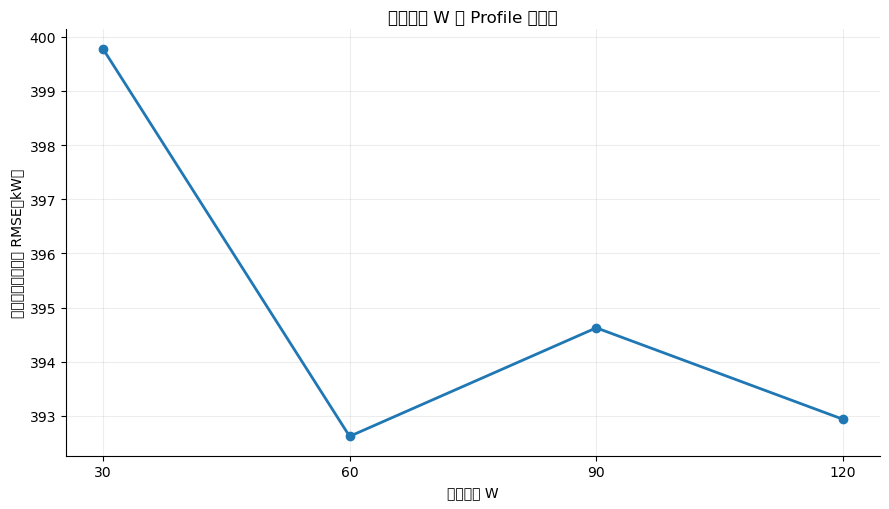

In [5]:

d = prof[prof["parameter"] == "W"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.0, 5.2))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(
    d["fixed_value"].astype(str),
    rotation=25 if "W" in ["hL","hP","calL","calP"] else 0,
    ha="right" if "W" in ["hL","hP","calL","calP"] else "center",
)
ax.set_xlabel("历史窗口 W")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("历史窗口 W 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### Load PCA维数 K_L

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
4,KL,1,416.1443,5.9908,30,1,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual2,0.1,30.0
5,KL,2,393.0214,0.1014,60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0
6,KL,3,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
7,KL,4,392.7215,0.0250,60,4,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,10.0
8,KL,5,392.9382,0.0802,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0


C:\Users\HP\AppData\Local\Temp\ipykernel_37148\984504226.py:19: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\984504226.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\984504226.py:19: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\984504226.py:19: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\984504226.py:19: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\984504226.py:19: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-

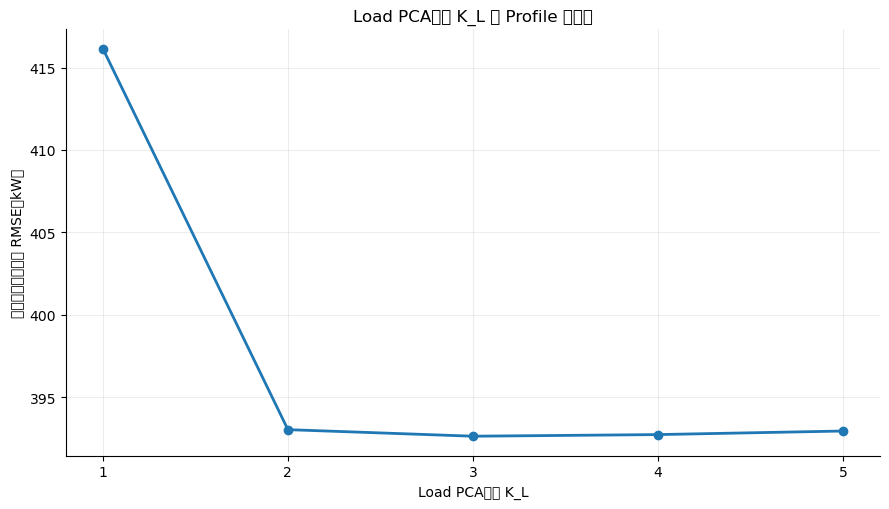

In [6]:

d = prof[prof["parameter"] == "KL"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.0, 5.2))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(
    d["fixed_value"].astype(str),
    rotation=25 if "KL" in ["hL","hP","calL","calP"] else 0,
    ha="right" if "KL" in ["hL","hP","calL","calP"] else "center",
)
ax.set_xlabel("Load PCA维数 K_L")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("Load PCA维数 K_L 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### PV PCA维数 K_P

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
9,KP,1,401.1565,2.1734,60,3,1,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,1.0,3.0
10,KP,2,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
11,KP,3,395.9150,0.8384,120,5,3,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
12,KP,4,392.9382,0.0802,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0


C:\Users\HP\AppData\Local\Temp\ipykernel_37148\3640387580.py:19: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\3640387580.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\3640387580.py:19: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\3640387580.py:19: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\3640387580.py:19: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\3640387580.py:19: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEO

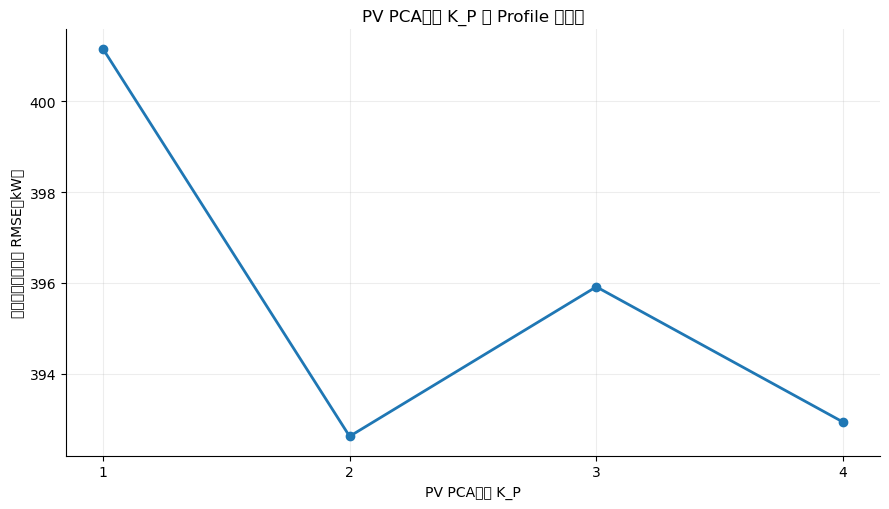

In [7]:

d = prof[prof["parameter"] == "KP"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.0, 5.2))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(
    d["fixed_value"].astype(str),
    rotation=25 if "KP" in ["hL","hP","calL","calP"] else 0,
    ha="right" if "KP" in ["hL","hP","calL","calP"] else "center",
)
ax.set_xlabel("PV PCA维数 K_P")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("PV PCA维数 K_P 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### Load历史状态

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
13,hL,H0_lag1,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
14,hL,H1_lag1_lag7,393.0214,0.1014,60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0
15,hL,H2_lag1_lag7_mean7,394.6270,0.5104,90,3,2,H2_lag1_lag7_mean7,H2_lag1_lag7_mean7,fri_sat,annual2,3.0,10.0
16,hL,H3_lag1_lag7_mean7_trend7,394.9553,0.5940,90,3,2,H3_lag1_lag7_mean7_trend7,H2_lag1_lag7_mean7,weekday7,annual2,0.1,10.0


C:\Users\HP\AppData\Local\Temp\ipykernel_37148\945967718.py:19: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\945967718.py:19: UserWarning: Glyph 21490 (\N{CJK UNIFIED IDEOGRAPH-53F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\945967718.py:19: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\945967718.py:19: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\945967718.py:19: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\945967718.py:19: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-

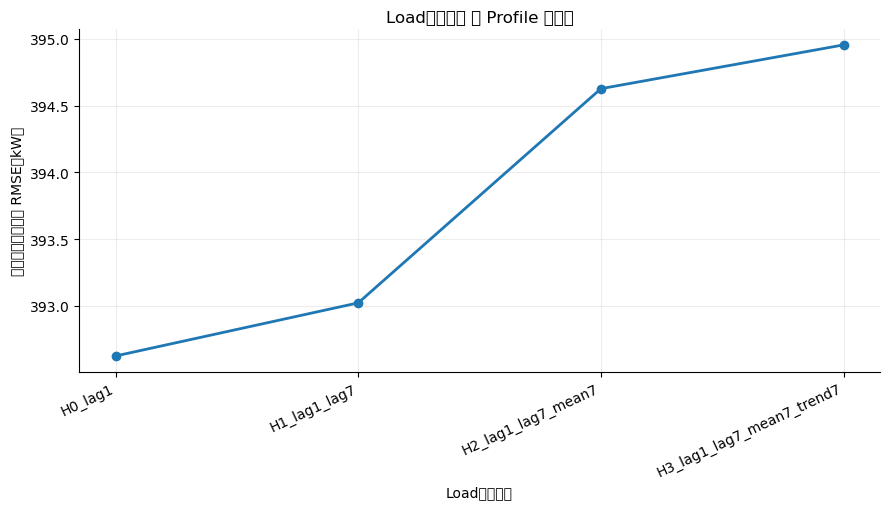

In [8]:

d = prof[prof["parameter"] == "hL"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.0, 5.2))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(
    d["fixed_value"].astype(str),
    rotation=25 if "hL" in ["hL","hP","calL","calP"] else 0,
    ha="right" if "hL" in ["hL","hP","calL","calP"] else "center",
)
ax.set_xlabel("Load历史状态")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("Load历史状态 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### PV历史状态

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
17,hP,H0_lag1,392.9382,0.0802,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
18,hP,H1_lag1_lag7,397.4976,1.2415,120,5,2,H0_lag1,H1_lag1_lag7,weekday7,annual2,0.1,1.0
19,hP,H2_lag1_lag7_mean7,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
20,hP,H3_lag1_lag7_mean7_trend7,393.7317,0.2823,60,3,2,H0_lag1,H3_lag1_lag7_mean7_trend7,weekday7,annual1,0.3,3.0


C:\Users\HP\AppData\Local\Temp\ipykernel_37148\1915703145.py:19: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\1915703145.py:19: UserWarning: Glyph 21490 (\N{CJK UNIFIED IDEOGRAPH-53F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\1915703145.py:19: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\1915703145.py:19: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\1915703145.py:19: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\1915703145.py:19: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEO

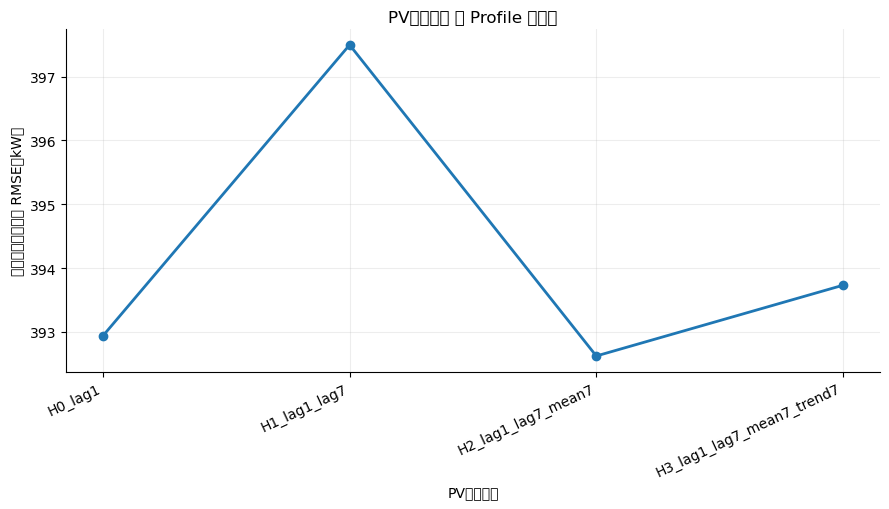

In [9]:

d = prof[prof["parameter"] == "hP"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.0, 5.2))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(
    d["fixed_value"].astype(str),
    rotation=25 if "hP" in ["hL","hP","calL","calP"] else 0,
    ha="right" if "hP" in ["hL","hP","calL","calP"] else "center",
)
ax.set_xlabel("PV历史状态")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("PV历史状态 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### Load日历特征

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
21,calL,fri_sat,393.0214,0.1014,60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0
22,calL,weekday7,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
23,calL,fri_sat+annual1,394.0928,0.3743,60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual1,annual1,1.0,10.0
24,calL,fri_sat+annual2,393.9749,0.3443,60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,1.0,10.0


C:\Users\HP\AppData\Local\Temp\ipykernel_37148\4057121226.py:19: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\4057121226.py:19: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\4057121226.py:19: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\4057121226.py:19: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\4057121226.py:19: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\4057121226.py:19: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEO

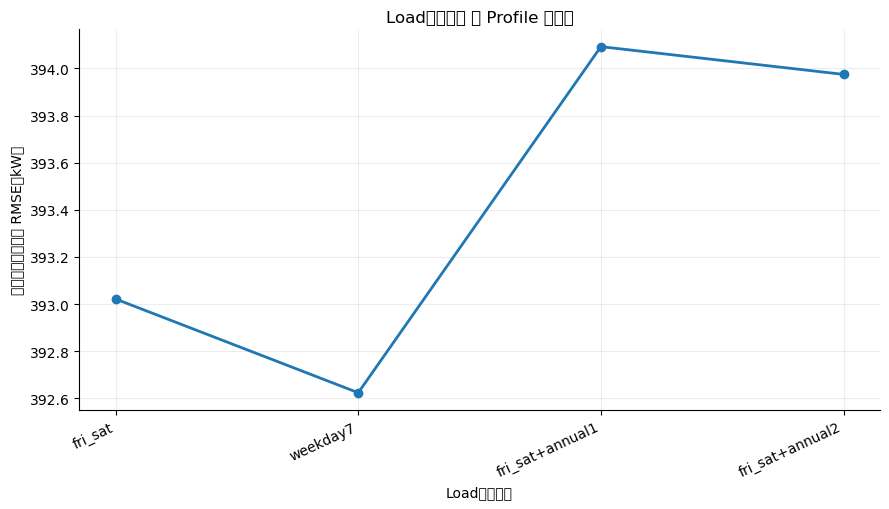

In [10]:

d = prof[prof["parameter"] == "calL"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.0, 5.2))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(
    d["fixed_value"].astype(str),
    rotation=25 if "calL" in ["hL","hP","calL","calP"] else 0,
    ha="right" if "calL" in ["hL","hP","calL","calP"] else "center",
)
ax.set_xlabel("Load日历特征")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("Load日历特征 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### PV日历特征

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
25,calP,annual1,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
26,calP,annual2,392.9382,0.0802,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
27,calP,weekday7+annual1,398.2602,1.4357,120,5,4,H0_lag1,H2_lag1_lag7_mean7,weekday7,weekday7+annual1,0.1,30.0
28,calP,weekday7+annual2,397.4445,1.2280,120,5,4,H0_lag1,H2_lag1_lag7_mean7,weekday7,weekday7+annual2,0.1,30.0


C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2762562449.py:19: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2762562449.py:19: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2762562449.py:19: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2762562449.py:19: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2762562449.py:19: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2762562449.py:19: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEO

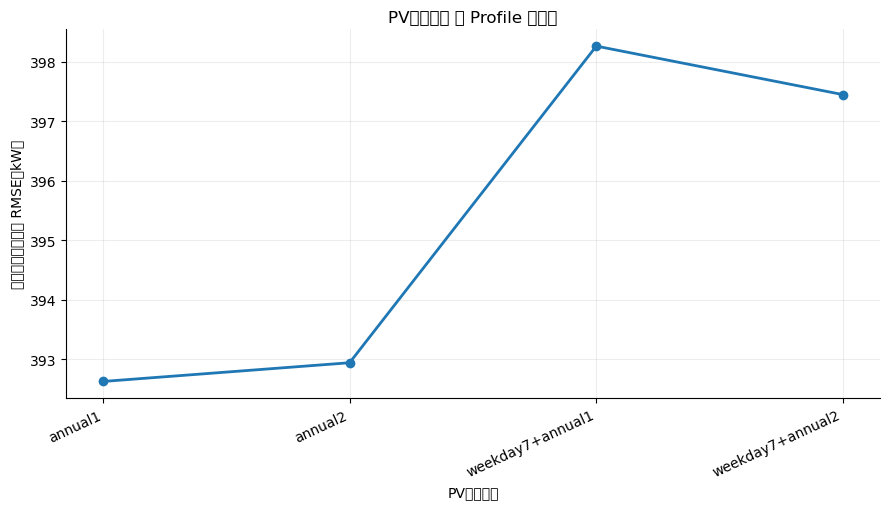

In [11]:

d = prof[prof["parameter"] == "calP"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.0, 5.2))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(
    d["fixed_value"].astype(str),
    rotation=25 if "calP" in ["hL","hP","calL","calP"] else 0,
    ha="right" if "calP" in ["hL","hP","calL","calP"] else "center",
)
ax.set_xlabel("PV日历特征")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("PV日历特征 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### Load Ridge α_L

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
29,alphaL,0.1,392.7215,0.0250,60,4,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,10.0
30,alphaL,0.3,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
31,alphaL,1.0,393.3500,0.1851,60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,1.0,10.0
32,alphaL,3.0,394.2746,0.4206,60,3,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,3.0,3.0
33,alphaL,10.0,396.6417,1.0235,120,4,4,H1_lag1_lag7,H0_lag1,fri_sat,annual2,10.0,3.0
34,alphaL,30.0,403.6769,2.8153,120,4,4,H2_lag1_lag7_mean7,H0_lag1,fri_sat,annual2,30.0,3.0
35,alphaL,100.0,435.4960,10.9196,120,4,4,H3_lag1_lag7_mean7_trend7,H2_lag1_lag7_mean7,fri_sat+annual1,annual1,100.0,30.0


C:\Users\HP\AppData\Local\Temp\ipykernel_37148\4173111304.py:19: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\4173111304.py:19: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\4173111304.py:19: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\4173111304.py:19: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\4173111304.py:19: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\4173111304.py:19: UserWarning: Glyph 20928 (\N{CJK UNIFIED IDEO

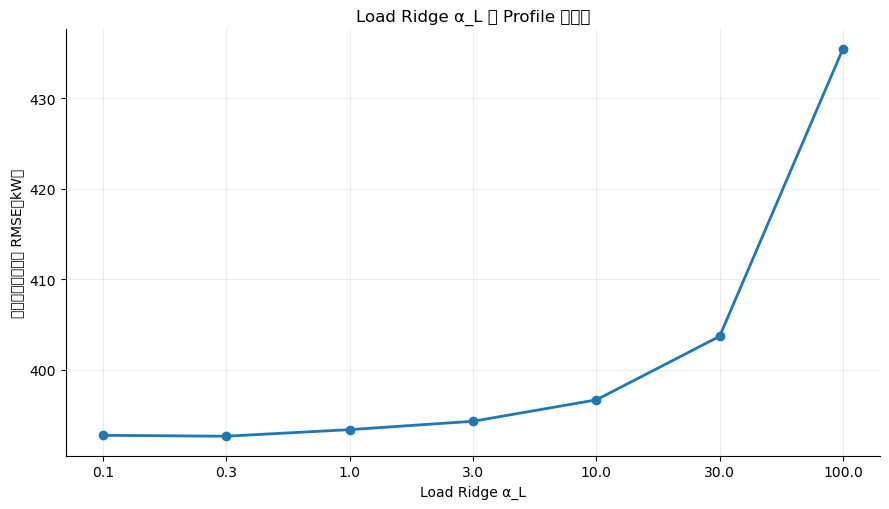

In [12]:

d = prof[prof["parameter"] == "alphaL"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.0, 5.2))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(
    d["fixed_value"].astype(str),
    rotation=25 if "alphaL" in ["hL","hP","calL","calP"] else 0,
    ha="right" if "alphaL" in ["hL","hP","calL","calP"] else "center",
)
ax.set_xlabel("Load Ridge α_L")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("Load Ridge α_L 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### PV Ridge α_P

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
36,alphaP,0.1,398.4054,1.4727,120,5,2,H0_lag1,H0_lag1,weekday7,annual2,0.1,0.1
37,alphaP,0.3,395.3215,0.6872,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,0.3
38,alphaP,1.0,392.9382,0.0802,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
39,alphaP,3.0,392.7362,0.0288,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,3.0
40,alphaP,10.0,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
41,alphaP,30.0,395.1183,0.6355,120,5,4,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual2,0.1,30.0
42,alphaP,100.0,398.8843,1.5947,120,5,4,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual2,0.1,100.0


C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2424516954.py:19: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2424516954.py:19: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2424516954.py:19: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2424516954.py:19: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2424516954.py:19: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\2424516954.py:19: UserWarning: Glyph 20928 (\N{CJK UNIFIED IDEO

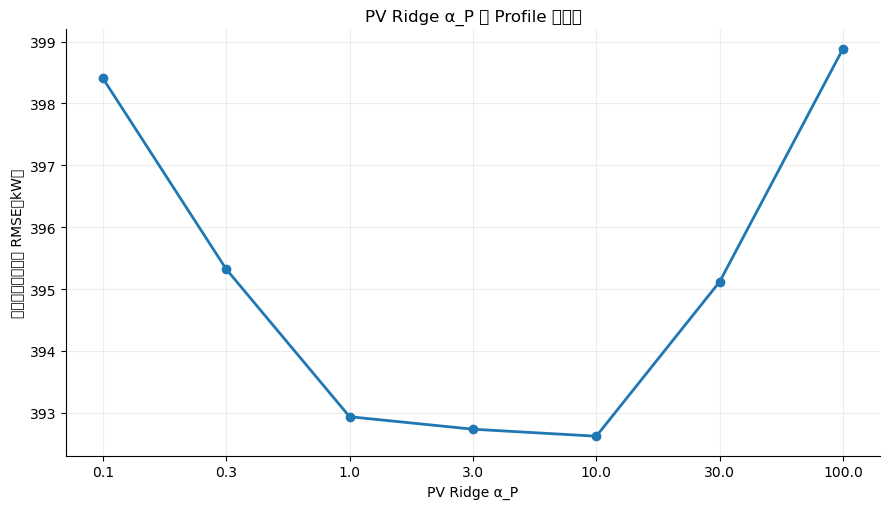

In [13]:

d = prof[prof["parameter"] == "alphaP"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.0, 5.2))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(
    d["fixed_value"].astype(str),
    rotation=25 if "alphaP" in ["hL","hP","calL","calP"] else 0,
    ha="right" if "alphaP" in ["hL","hP","calL","calP"] else "center",
)
ax.set_xlabel("PV Ridge α_P")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("PV Ridge α_P 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()



## 4. 分月稳定性检查：防止“联合最优只是撞中某个月”

联合搜索仍然是在同一个 May–Aug 公共验证区上完成的，因此还要检查：

> 最优配置是不是只在某一个月份特别好，其他月份却明显变差？

本检查从每个 W 的联合搜索结果中取 Top 10 配置，重新计算 May / Jun / Jul / Aug 的月度 RMSE。

这里**不改变主优化目标**。主目标仍是 pooled global RMSE；分月结果只作为 robustness check。


In [14]:

cols = [
    "W","rank","KL","KP","hL","hP","calL","calP","alphaL","alphaP",
    "overall_rmse","May_rmse","Jun_rmse","Jul_rmse","Aug_rmse",
    "monthly_mean_rmse","monthly_sd_rmse","worst_month_rmse","monthly_cv_pct"
]
display(monthly[cols].sort_values(["W","rank"]).round(4))


,W,rank,KL,KP,hL,hP,calL,calP,alphaL,alphaP,overall_rmse,May_rmse,Jun_rmse,Jul_rmse,Aug_rmse,monthly_mean_rmse,monthly_sd_rmse,worst_month_rmse,monthly_cv_pct
30,30,1,2,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual2,0.1,30.0,399.7803,378.7611,439.4639,386.8474,392.5968,399.4173,23.6375,439.4639,5.9180
31,30,2,2,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual2,0.3,30.0,400.2029,382.7008,434.7544,387.9410,394.4748,399.9678,20.5127,434.7544,5.1286
33,30,3,2,2,H0_lag1,H3_lag1_lag7_mean7_trend7,fri_sat,annual2,0.1,30.0,400.5291,380.0133,439.5207,387.9428,393.2720,400.1872,23.1940,439.5207,5.7958
32,30,4,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual2,0.3,30.0,400.6208,379.1893,445.6074,386.2069,389.4994,400.1257,26.5216,445.6074,6.6283
36,30,5,2,2,H0_lag1,H3_lag1_lag7_mean7_trend7,fri_sat,annual2,0.3,30.0,400.9203,383.8354,434.7759,388.9900,395.2067,400.7020,20.0803,434.7759,5.0113
34,30,6,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual2,0.1,30.0,401.0932,376.4496,450.9956,386.4293,387.8603,400.4337,29.5210,450.9956,7.3723
35,30,7,2,1,H0_lag1,H0_lag1,fri_sat,annual2,0.1,3.0,401.1600,384.6031,443.5294,377.4944,397.1550,400.6955,25.7125,443.5294,6.4170
38,30,8,2,1,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual2,0.1,30.0,401.2086,381.1131,442.0075,382.5700,397.4992,400.7974,24.6417,442.0075,6.1482
37,30,9,2,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,30.0,401.2254,378.9667,443.7171,388.3170,392.1667,400.7919,25.2435,443.7171,6.2984
39,30,10,2,1,H0_lag1,H3_lag1_lag7_mean7_trend7,fri_sat,annual2,0.1,30.0,401.2418,380.9036,442.0577,383.8269,396.5658,400.8385,24.5157,442.0577,6.1161



### 4.1 不同判据下的“赢家”

我们同时看三个判据：

1. **pooled overall RMSE**：原联合搜索的主目标；
2. **mean monthly RMSE**：四个月 RMSE 的平均值，用于检查跨月平均稳定性；
3. **minimax worst month**：让最差月份尽可能小，只作为更保守的鲁棒性参考。

如果 pooled overall 与 mean monthly 选择同一配置，说明联合最优不是单月偶然造成的。


In [15]:

show_cols = [
    "criterion","W","KL","KP","hL","hP","calL","calP","alphaL","alphaP",
    "overall_rmse","monthly_mean_rmse","monthly_sd_rmse","worst_month_rmse"
]
display(monthly_winners[show_cols].round(4))


,criterion,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP,overall_rmse,monthly_mean_rmse,monthly_sd_rmse,worst_month_rmse
0,pooled_overall_rmse,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0,392.6232,392.082,26.7784,436.3568
1,mean_monthly_rmse,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0,392.6232,392.082,26.7784,436.3568
2,minimax_worst_month,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.3,1.0,393.4077,393.158,20.4667,427.0290



当前结果中：

- pooled overall RMSE 最优：**W=60 的同一配置**；
- mean monthly RMSE 最优：仍然是**同一个 W=60 配置**；
- minimax worst-month 最优：W=120 的一组配置。

因此，若目标仍然是平均预测精度，W=60 的联合最优得到分月检查支持；  
如果把“最差月份风险”作为第一目标，则 W=120 会更保守、更平稳。

本题当前主目标是净负荷总体 RMSE，因此不因为 minimax 结果而改选 W=120。


,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP,overall_rmse,monthly_mean_rmse,monthly_sd_rmse,worst_month_rmse,monthly_cv_pct
0,30,2,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual2,0.1,30.0,399.7803,399.4173,23.6375,439.4639,5.9180
1,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0,392.6232,392.0820,26.7784,436.3568,6.8298
2,90,3,2,H2_lag1_lag7_mean7,H2_lag1_lag7_mean7,weekday7,annual2,1.0,10.0,394.7207,393.7321,34.1765,451.6396,8.6801
3,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0,392.9382,392.6582,21.1213,427.1400,5.3791


C:\Users\HP\AppData\Local\Temp\ipykernel_37148\119453825.py:19: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\119453825.py:19: UserWarning: Glyph 21490 (\N{CJK UNIFIED IDEOGRAPH-53F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\119453825.py:19: UserWarning: Glyph 31383 (\N{CJK UNIFIED IDEOGRAPH-7A97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\119453825.py:19: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\119453825.py:19: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_37148\119453825.py:19: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-

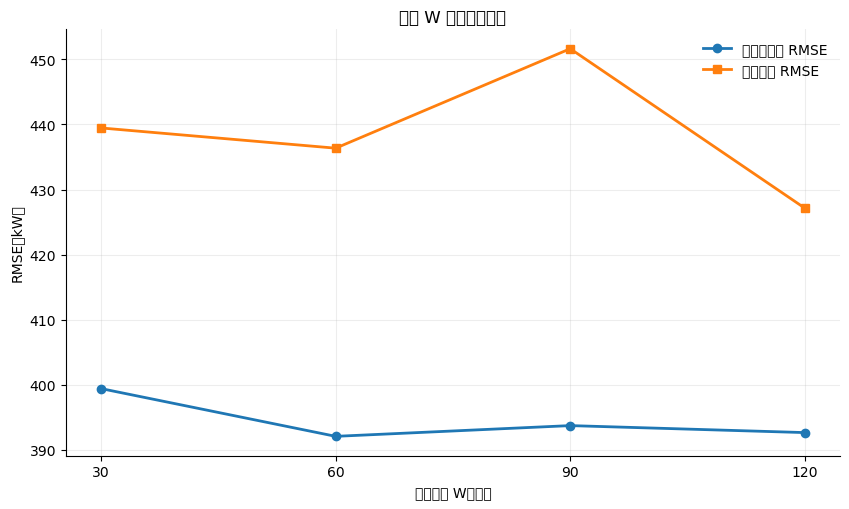

In [16]:

# 每个 W 在自己的 Top 10 中，找月均 RMSE 最小的配置
show_cols = [
    "W","KL","KP","hL","hP","calL","calP","alphaL","alphaP",
    "overall_rmse","monthly_mean_rmse","monthly_sd_rmse","worst_month_rmse","monthly_cv_pct"
]
display(monthly_byW[show_cols].round(4))

fig, ax = plt.subplots(figsize=(8.6,5.2))
ax.plot(monthly_byW["W"], monthly_byW["monthly_mean_rmse"], marker="o", linewidth=2, label="四个月平均 RMSE")
ax.plot(monthly_byW["W"], monthly_byW["worst_month_rmse"], marker="s", linewidth=2, label="最差月份 RMSE")
ax.set_xlabel("历史窗口 W（天）")
ax.set_ylabel("RMSE（kW）")
ax.set_title("不同 W 的跨月稳定性")
ax.set_xticks([30,60,90,120])
ax.grid(alpha=.22)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()



## 5. 可以冻结的当前模型

在当前候选空间与公共验证区下：

$$
W=60,\quad K_L=3,\quad K_P=2,
$$

$$
h_L=lag1,
$$

$$
h_P=lag1+lag7+mean7,
$$

$$
C_L=weekday7,\qquad C_P=annual1,
$$

$$
\alpha_L=0.3,\qquad \alpha_P=10.
$$

这套配置同时满足：

- pooled global RMSE 最低；
- Top 配置分月检查中，四个月平均 RMSE 仍最低；
- 没有出现“只靠某一个月份拉低总体误差”的明显证据。

因此可以把它作为**当前冻结候选模型**。

需要注意：W=120 的最差月份表现更稳定，因此论文应写“W=60 在总体精度目标下最优”，而不要写成“W=60 在所有稳定性指标上都绝对最好”。



## 6. 下一步逻辑

到这里为止：

1. “W=60 借用 W30 参数”的逻辑问题已经解决；
2. “联合搜索可能只撞中某个月”的问题已通过分月检查进一步核验；
3. Sep–Dec 仍然未参与选择。

下一步才是：

- 冻结上述参数；
- 首次计算 Sep–Dec 独立测试；
- 在**同一冻结参数**下重新生成概率场景与风险分位数策略。

不要再用旧 W30 参数，也不要用“只改 W=60”的过渡策略 Notebook。
